In [1]:
install.packages("neuralnet")
library('neuralnet')

Warning message:
"dependency 'MASS' is not available"

package 'neuralnet' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\moham\AppData\Local\Temp\Rtmp08AULO\downloaded_packages


Warning message:
"package 'neuralnet' was built under R version 3.6.3"

In [2]:
sam_train <- read.csv("Sameena-Train.csv")
test_data <- read.csv("Testset.csv")

In [3]:
sum(is.na(test_data))

[1] 0

In [4]:
summary(sam_train)

         ï..ID        gender      Management    USAcitizen Married  
 SAMEENA1   :  1   Female:495   Min.   :0.000   No :515    No :698  
 SAMEENA10  :  1   Male  :505   1st Qu.:0.000   Yes:485    Yes:302  
 SAMEENA100 :  1                Median :0.000                       
 SAMEENA1000:  1                Mean   :0.165                       
 SAMEENA101 :  1                3rd Qu.:0.000                       
 SAMEENA102 :  1                Max.   :1.000                       
 (Other)    :994                                                    
 MonthsInUnion    ContinuingEd      FeatureA        Connectivity
 Min.   :  0.00   No : 75      Maryville: 75   Dial-in    : 78  
 1st Qu.:  9.00   Yes:925      No       :495   DSL        :320  
 Median : 29.00                Yes      :430   Fiber optic:485  
 Mean   : 33.77                                onlyViaER  :117  
 3rd Qu.: 54.25                                                 
 Max.   :661.00                                           

In [5]:
summary(test_data)

     ï..ID           gender      Management    USAcitizen Married  
 Min.   :   1.0   Female:468   Min.   :0.000   No :494    No :701  
 1st Qu.: 250.8   Male  :532   1st Qu.:0.000   Yes:506    Yes:299  
 Median : 500.5                Median :0.000                       
 Mean   : 500.5                Mean   :0.169                       
 3rd Qu.: 750.2                3rd Qu.:0.000                       
 Max.   :1000.0                Max.   :1.000                       
                                                                   
 MonthsInUnion    ContinuingEd      FeatureA        Connectivity
 Min.   :  0.00   No : 78      Maryville: 78   Dial-in    : 91  
 1st Qu.:  8.00   Yes:922      No       :477   DSL        :340  
 Median : 31.00                Yes      :445   Fiber optic:439  
 Mean   : 34.33                                onlyViaER  :130  
 3rd Qu.: 55.00                                                 
 Max.   :605.00                                                 
 

In [6]:
str(sam_train)

'data.frame':	1000 obs. of  21 variables:
 $ ï..ID           : Factor w/ 1000 levels "SAMEENA1","SAMEENA10",..: 1 113 224 335 446 557 668 779 890 2 ...
 $ gender          : Factor w/ 2 levels "Female","Male": 2 2 1 1 2 2 1 1 2 2 ...
 $ Management      : int  0 0 0 0 0 1 0 0 0 0 ...
 $ USAcitizen      : Factor w/ 2 levels "No","Yes": 1 1 2 1 1 1 1 2 2 2 ...
 $ Married         : Factor w/ 2 levels "No","Yes": 1 1 2 1 1 1 1 2 1 2 ...
 $ MonthsInUnion   : int  4 1 71 61 16 13 7 57 37 35 ...
 $ ContinuingEd    : Factor w/ 2 levels "No","Yes": 2 2 2 2 2 2 2 2 2 2 ...
 $ FeatureA        : Factor w/ 3 levels "Maryville","No",..: 2 2 3 3 2 2 2 2 2 2 ...
 $ Connectivity    : Factor w/ 4 levels "Dial-in","DSL",..: 3 4 2 2 3 3 2 2 3 1 ...
 $ FeatureC        : Factor w/ 3 levels "Maryville","No",..: 2 1 3 3 2 2 3 3 2 1 ...
 $ FeatureD        : Factor w/ 3 levels "Maryville","No",..: 2 1 3 3 2 2 3 2 2 1 ...
 $ FeatureE        : Factor w/ 3 levels "Maryville","No",..: 2 1 3 3 2 2 3 2 3 1 ...
 $ Featu

In [7]:
str(test_data)

'data.frame':	1000 obs. of  20 variables:
 $ ï..ID           : int  1 2 3 4 5 6 7 8 9 10 ...
 $ gender          : Factor w/ 2 levels "Female","Male": 1 1 1 1 1 1 1 2 2 2 ...
 $ Management      : int  0 0 1 0 1 0 0 0 0 0 ...
 $ USAcitizen      : Factor w/ 2 levels "No","Yes": 1 1 2 1 2 1 2 2 2 2 ...
 $ Married         : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 2 2 1 ...
 $ MonthsInUnion   : int  51 7 70 36 61 52 72 58 50 65 ...
 $ ContinuingEd    : Factor w/ 2 levels "No","Yes": 1 2 2 2 2 2 2 2 2 2 ...
 $ FeatureA        : Factor w/ 3 levels "Maryville","No",..: 1 3 3 3 3 2 3 3 3 3 ...
 $ Connectivity    : Factor w/ 4 levels "Dial-in","DSL",..: 2 2 3 2 3 2 1 3 3 3 ...
 $ FeatureC        : Factor w/ 3 levels "Maryville","No",..: 2 2 2 3 2 3 1 2 3 3 ...
 $ FeatureD        : Factor w/ 3 levels "Maryville","No",..: 3 2 2 2 3 2 1 2 2 2 ...
 $ FeatureE        : Factor w/ 3 levels "Maryville","No",..: 3 2 2 2 3 2 1 3 3 3 ...
 $ FeatureF        : Factor w/ 3 levels "Maryville","No",..: 2 3 

In [8]:
head(sam_train)

ï..ID,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,FeatureA,Connectivity,FeatureC,...,FeatureE,FeatureF,FeatureG,FeatureB,DuesFrequency,PaperlessBilling,PaymentMethod,MonthlyDues,TotalDues,LeftUnion
SAMEENA1,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,81,341,Yes
SAMEENA2,Male,0,No,No,1,Yes,No,onlyViaER,Maryville,...,Maryville,Maryville,Maryville,Maryville,Month-to-month,No,Mailed check,19,19,No
SAMEENA3,Female,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),90,6343,No
SAMEENA4,Female,0,No,No,61,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,90,5309,No
SAMEENA5,Male,0,No,No,16,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),75,1171,No
SAMEENA6,Male,1,No,No,13,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,91,1201,Yes


In [9]:
tail(sam_train)

,ï..ID,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,FeatureA,Connectivity,FeatureC,...,FeatureE,FeatureF,FeatureG,FeatureB,DuesFrequency,PaperlessBilling,PaymentMethod,MonthlyDues,TotalDues,LeftUnion
995,SAMEENA995,Female,0,Yes,Yes,65,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109,7338,No
996,SAMEENA996,Male,0,No,No,46,No,Maryville,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),30,1380,Yes
997,SAMEENA997,Male,1,Yes,No,17,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,76,1233,Yes
998,SAMEENA998,Male,0,No,No,27,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),101,2673,No
999,SAMEENA999,Male,0,Yes,No,21,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,111,2317,Yes
1000,SAMEENA1000,Female,0,Yes,Yes,72,No,Maryville,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),64,4528,No


In [10]:
#Check missing values
sum(is.na(sam_train))

[1] 0

In [11]:
unique<-unique(sam_train$TotalDues)

#Converting #VALUE! to NA
sam_train$TotalDues[sam_train$TotalDues=="VALUES!"] <- NA

#Converting Totaldues into the numeric
sam_train$TotalDues <- as.numeric(sam_train$TotalDues)

In [12]:
categorical_cols <- sum(sapply(sam_train,is.character))
factor_cols <-sum(sapply(sam_train, is.factor))
numeric_cols1 <- sum(sapply(sam_train, is.numeric) & names(sam_train)!= 'LeftUnion')
numeric_cols <- sapply(sam_train, is.numeric) & names(sam_train)!= 'LeftUnion'

print(paste("Number of categorical columns:", categorical_cols))
print(paste("Number of factor columns:", factor_cols))
print(paste("Number of numeric columns:", numeric_cols1))

[1] "Number of categorical columns: 0"
[1] "Number of factor columns: 17"
[1] "Number of numeric columns: 4"


In [13]:
#Standerdized the numerical data
numfun <- function(x){
    result <- (x-min(x))/(max(x) - min(x))
    return (result)
}

# with apply() normalize the column here sam_parameter 2 indicates that numfun should apply to the column wise
sam_train[, numeric_cols] <- apply(sam_train[, numeric_cols],2,numfun)

In [14]:
class(sam_train$TotalDues)

[1] "numeric"

In [15]:
names(sam_train)

[1] "ï..ID"            "gender"           "Management"       "USAcitizen"      
 [5] "Married"          "MonthsInUnion"    "ContinuingEd"     "FeatureA"        
 [9] "Connectivity"     "FeatureC"         "FeatureD"         "FeatureE"        
[13] "FeatureF"         "FeatureG"         "FeatureB"         "DuesFrequency"   
[17] "PaperlessBilling" "PaymentMethod"    "MonthlyDues"      "TotalDues"       
[21] "LeftUnion"

In [16]:
#Converting binary classification into 1 and 0 using ifelse condition
sam_train$LeftUnion <- ifelse(sam_train$LeftUnion=="Yes", 1,0)
sam_train$gender <- ifelse(sam_train$gender=="Yes", 1,0)
sam_train$USAcitizen <- ifelse(sam_train$USAcitizen=="Yes", 1,0)
sam_train$Married <- ifelse(sam_train$Married=="Yes", 1,0)
sam_train$ContinuingEd <- ifelse(sam_train$ContinuingEd=="Yes", 1,0)
sam_train$PaperlessBilling <- ifelse(sam_train$PaperlessBilling=="Yes", 1,0)

# Combine all categorical columns to be encoded
cat_columns <- c("FeatureA", "Connectivity", "FeatureC", "FeatureD", "FeatureE", "FeatureF",
                 "FeatureG", "FeatureB", "DuesFrequency", "PaymentMethod")

# Using one hot-encoding for multiple classfication
encoded_cols <- cbind(
    
    model.matrix(~ FeatureA - 1, data = sam_train),
    model.matrix(~ Connectivity - 1, data = sam_train),
    model.matrix(~ FeatureC - 1, data = sam_train),
    model.matrix(~ FeatureD - 1, data = sam_train),
    model.matrix(~ FeatureE - 1, data = sam_train),
    model.matrix(~ FeatureF - 1, data = sam_train),
    model.matrix(~ FeatureG - 1, data = sam_train),
    model.matrix(~ FeatureB - 1, data = sam_train),
    model.matrix(~ DuesFrequency - 1, data = sam_train),
    model.matrix(~ PaymentMethod - 1, data = sam_train)
)
# Combine the encoded columns with the original data
sam_train <- cbind(sam_train[, !(names(sam_train) %in% cat_columns)], encoded_cols)

In [17]:
dim(sam_train)
dim(encoded_cols)

[1] 1000   43

[1] 1000   32

In [18]:
any(duplicated(colnames(encoded_cols)))


[1] FALSE

In [19]:
names(sam_train)

[1] "ï..ID"                                 
 [2] "gender"                                
 [3] "Management"                            
 [4] "USAcitizen"                            
 [5] "Married"                               
 [6] "MonthsInUnion"                         
 [7] "ContinuingEd"                          
 [8] "PaperlessBilling"                      
 [9] "MonthlyDues"                           
[10] "TotalDues"                             
[11] "LeftUnion"                             
[12] "FeatureAMaryville"                     
[13] "FeatureANo"                            
[14] "FeatureAYes"                           
[15] "ConnectivityDial-in"                   
[16] "ConnectivityDSL"                       
[17] "ConnectivityFiber optic"               
[18] "ConnectivityonlyViaER"                 
[19] "FeatureCMaryville"                     
[20] "FeatureCNo"                            
[21] "FeatureCYes"                           
[22] "FeatureDMaryville"                     
[23] "FeatureDNo"                            
[24] "FeatureDYes"                           
[25] "FeatureEMaryville"                     
[26] "FeatureENo"                            
[27] "FeatureEYes"                           
[28] "FeatureFMaryville"                     
[29] "FeatureFNo"                            
[30] "FeatureFYes"                           
[31] "FeatureGMaryville"                     
[32] "FeatureGNo"                            
[33] "FeatureGYes"                           
[34] "FeatureBMaryville"                     
[35] "FeatureBNo"                            
[36] "FeatureBYes"                           
[37] "DuesFrequencyMonth-to-month"           
[38] "DuesFrequencyOne year"                 
[39] "DuesFrequencyTwo year"                 
[40] "PaymentMethodBank transfer (automatic)"
[41] "PaymentMethodCredit card (automatic)"  
[42] "PaymentMethodElectronic check"         
[43] "PaymentMethodMailed check"

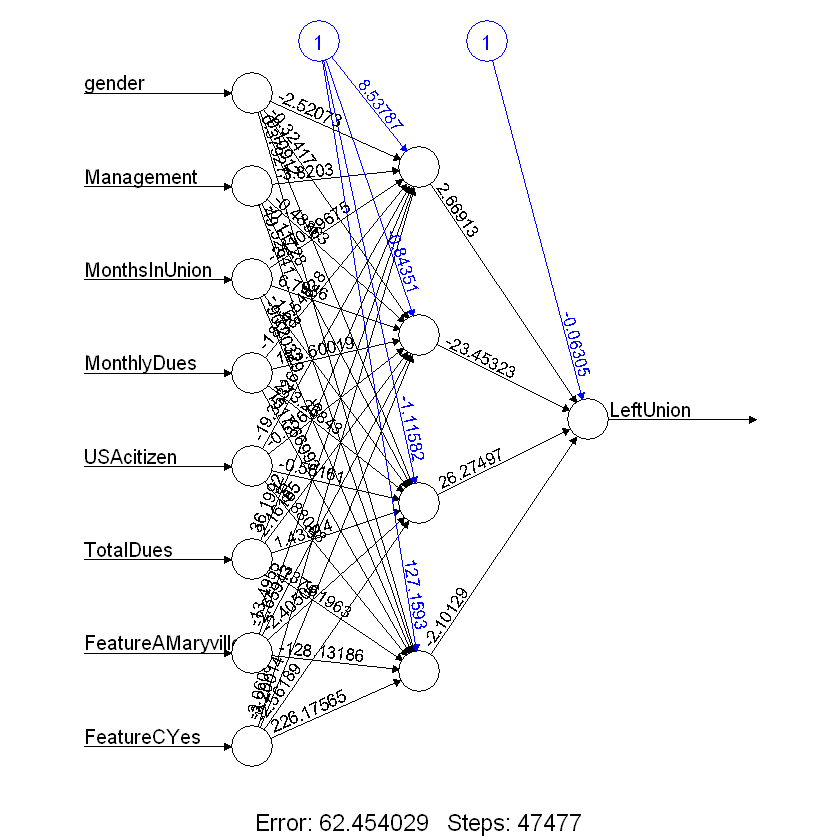

In [20]:
neural_network <- neuralnet(LeftUnion~gender+Management+MonthsInUnion+MonthlyDues+USAcitizen+ TotalDues +
                            FeatureAMaryville +FeatureCYes,
                            sam_train, hidden=4, act.fct='logistic', linear.output=FALSE)

plot(neural_network, rep='best')

In [21]:
# unique<- unique(test_data$TotalDues)

# test_data$TotalDues[test_data$TotalDues=="#VALUE!"] <-NA

test_data$TotalDues <- as.numeric(test_data$TotalDues)                     

In [22]:
#Standerdized the numerical data
numfun <- function(x){
    result <- (x-min(x))/(max(x) - min(x))
    return (result)
}

# with apply() normalize the column here sam_parameter 2 indicates that numfun should apply to the column wise
test_data[, numeric_cols] <- apply(test_data[, numeric_cols],2,numfun)
                                   
                                   
#Converting binary classification into 1 and 0 using ifelse condition
test_data$gender <- ifelse(test_data$gender=="Yes", 1,0)
test_data$USAcitizen <- ifelse(test_data$USAcitizen=="Yes", 1,0)
test_data$Married <- ifelse(test_data$Married=="Yes", 1,0)
test_data$ContinuingEd <- ifelse(test_data$ContinuingEd=="Yes", 1,0)
test_data$PaperlessBilling <- ifelse(test_data$PaperlessBilling=="Yes", 1,0)



# Combine all categorical columns to be encoded
cat_columns <- c("FeatureA", "Connectivity", "FeatureC", "FeatureD", "FeatureE", "FeatureF",
                 "FeatureG", "FeatureB", "DuesFrequency", "PaymentMethod")

# Using one hot-encoding for multiple classfication
encoded_cols <- cbind(
    
    model.matrix(~ FeatureA - 1, data = test_data),
    model.matrix(~ Connectivity - 1, data = test_data),
    model.matrix(~ FeatureC - 1, data = test_data),
    model.matrix(~ FeatureD - 1, data = test_data),
    model.matrix(~ FeatureE - 1, data = test_data),
    model.matrix(~ FeatureF - 1, data = test_data),
    model.matrix(~ FeatureG - 1, data = test_data),
    model.matrix(~ FeatureB - 1, data = test_data),
    model.matrix(~ DuesFrequency - 1, data = test_data),
    model.matrix(~ PaymentMethod - 1, data = test_data)
)



# Combine the encoded columns with the original data
test_data<- cbind(test_data[, !(names(test_data) %in% cat_columns)], encoded_cols)

In [23]:
sum(is.na(test_data))

[1] 0

In [24]:
head(test_data)

ï..ID,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,PaperlessBilling,MonthlyDues,TotalDues,...,FeatureBMaryville,FeatureBNo,FeatureBYes,DuesFrequencyMonth-to-month,DuesFrequencyOne year,DuesFrequencyTwo year,PaymentMethodBank transfer (automatic),PaymentMethodCredit card (automatic),PaymentMethodElectronic check,PaymentMethodMailed check
1,0,0,0,0,0.08429752,0,1,0.003479853,0.3957845,...,0,0,1,0,1,0,0,1,0,0
2,0,0,0,0,0.01157025,1,1,0.005219780,0.6686183,...,0,0,1,1,0,0,0,0,1,0
3,0,1,1,0,0.11570248,1,1,0.005311355,0.6885246,...,0,1,0,0,0,1,0,1,0,0
4,0,0,0,0,0.05950413,1,0,0.003296703,0.2201405,...,0,1,0,0,1,0,0,0,0,1
5,0,1,1,0,0.10082645,1,1,0.007875458,0.8138173,...,0,0,1,0,1,0,0,1,0,0
6,0,0,0,0,0.08595041,1,1,0.002930403,0.3337237,...,0,1,0,1,0,0,1,0,0,0


In [25]:
names(test_data)

[1] "ï..ID"                                 
 [2] "gender"                                
 [3] "Management"                            
 [4] "USAcitizen"                            
 [5] "Married"                               
 [6] "MonthsInUnion"                         
 [7] "ContinuingEd"                          
 [8] "PaperlessBilling"                      
 [9] "MonthlyDues"                           
[10] "TotalDues"                             
[11] "FeatureAMaryville"                     
[12] "FeatureANo"                            
[13] "FeatureAYes"                           
[14] "ConnectivityDial-in"                   
[15] "ConnectivityDSL"                       
[16] "ConnectivityFiber optic"               
[17] "ConnectivityonlyViaER"                 
[18] "FeatureCMaryville"                     
[19] "FeatureCNo"                            
[20] "FeatureCYes"                           
[21] "FeatureDMaryville"                     
[22] "FeatureDNo"                            
[23] "FeatureDYes"                           
[24] "FeatureEMaryville"                     
[25] "FeatureENo"                            
[26] "FeatureEYes"                           
[27] "FeatureFMaryville"                     
[28] "FeatureFNo"                            
[29] "FeatureFYes"                           
[30] "FeatureGMaryville"                     
[31] "FeatureGNo"                            
[32] "FeatureGYes"                           
[33] "FeatureBMaryville"                     
[34] "FeatureBNo"                            
[35] "FeatureBYes"                           
[36] "DuesFrequencyMonth-to-month"           
[37] "DuesFrequencyOne year"                 
[38] "DuesFrequencyTwo year"                 
[39] "PaymentMethodBank transfer (automatic)"
[40] "PaymentMethodCredit card (automatic)"  
[41] "PaymentMethodElectronic check"         
[42] "PaymentMethodMailed check"

In [26]:
test_pred <- compute(neural_network, test_data)
head(test_pred$net.result, head=9)

0.13975861
0.30221959
0.06215581
0.12266880
0.53627134
0.06985741


In [27]:
predicted_probs <- test_pred$net.result

# Since you are doing binary classification, you can convert the predicted probabilities to class predictions (0 or 1)
predicted_classes <- ifelse(predicted_probs > 0.5, 1, 0)

# Compare the predicted classes with the actual classes in the training data
accuracy <- mean(predicted_classes == sam_train$LeftUnion)

# Print the accuracy of the model on the training data
print(paste("Accuracy on training data:", round(accuracy * 100, 2), "%"))

[1] "Accuracy on training data: 64.8 %"


In [28]:
output_col <- round(predicted_probs)
# output_col
# output_data <- data.frame(ID = test_data$ID, output= test_data$output_pred)

# length(test_data$ï..ID)
# Check the dimensions of test_data
dim(test_data)

# Check the length of output_col
length(output_col)

length(test_data$output_col)

[1] 1000   42

[1] 1000

[1] 0

In [29]:
# Create a new numeric ID column in the test data
test_data$ID <- 1:1000

# Combine ID and output_col into a data frame
output_data <- data.frame(ID = test_data$ID, output = output_col)

# Export the data frame as a CSV file
write.csv(output_data, "predicted_output.csv", row.names = FALSE)


In [30]:
# Create the output_data data frame with ID and output columns
output_data <- data.frame(ID = test_data$ID, output = output_col)

# Export the data frame as a CSV file
write.csv(output_data, "sameena_mujwar_prediction_.csv", row.names = FALSE)


In [31]:
sum(is.na(output_col))

[1] 0